# Batch Normalization & Layer Normalization

Implemented from scratch, validated against PyTorch, and stress-tested to show
*mechanistically* why normalizing activations stabilizes deep network training.

We answer four concrete questions with numbers:
1. What do BatchNorm and LayerNorm actually compute, and how do they differ?
2. Do they keep activation statistics stable as depth increases?
3. Why does BatchNorm let you use much larger learning rates?
4. When does LayerNorm work but BatchNorm fails (small batch / batch size 1)?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100

## 1. From-Scratch Implementations

**Batch Normalization (BatchNorm)** normalizes each feature *across the batch*:
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y_i = \gamma \hat{x}_i + \beta$$
where $\mu_B, \sigma_B^2$ are the mean and variance computed over the batch dimension.
During training, running averages of $\mu_B, \sigma_B^2$ are stored; at inference, those
running statistics replace the batch statistics.

**Layer Normalization (LayerNorm)** normalizes *across features within each sample*:
$$\hat{x}_i = \frac{x_i - \mu_L}{\sqrt{\sigma_L^2 + \epsilon}}, \qquad y_i = \gamma \hat{x}_i + \beta$$
where $\mu_L, \sigma_L^2$ are computed over the feature dimension for each sample independently.
No running statistics are needed — the normalization is the same at train and test time.

Both have learnable scale $\gamma$ and shift $\beta$ per feature, allowing the network to
undo normalization if needed.

In [2]:
class BatchNorm1d:
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        self.gamma = np.ones(num_features)
        self.beta = np.zeros(num_features)
        self.running_mean = np.zeros(num_features)
        self.running_var = np.ones(num_features)
        self.training = True
        self.cache = None

    def forward(self, x):
        if self.training:
            batch_mean = x.mean(axis=0)
            batch_var = x.var(axis=0)
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * batch_var
            mean, var = batch_mean, batch_var
        else:
            mean, var = self.running_mean, self.running_var
        x_hat = (x - mean) / np.sqrt(var + self.eps)
        out = self.gamma * x_hat + self.beta
        self.cache = (x, x_hat, mean, var)
        return out

    def backward(self, dout):
        x, x_hat, mean, var = self.cache
        N = x.shape[0]
        dgamma = np.sum(dout * x_hat, axis=0)
        dbeta = np.sum(dout, axis=0)
        dx_hat = dout * self.gamma
        dvar = np.sum(dx_hat * (x - mean), axis=0) * -0.5 * (var + self.eps) ** (-1.5)
        dmean = np.sum(dx_hat * -1 / np.sqrt(var + self.eps), axis=0) + dvar * np.mean(-2 * (x - mean), axis=0)
        dx = dx_hat / np.sqrt(var + self.eps) + dvar * 2 * (x - mean) / N + dmean / N
        return dx, dgamma, dbeta


class LayerNorm1d:
    def __init__(self, num_features, eps=1e-5):
        self.gamma = np.ones(num_features)
        self.beta = np.zeros(num_features)
        self.eps = eps
        self.cache = None

    def forward(self, x):
        mean = x.mean(axis=1, keepdims=True)
        var = x.var(axis=1, keepdims=True)
        x_hat = (x - mean) / np.sqrt(var + self.eps)
        out = self.gamma * x_hat + self.beta
        self.cache = (x, x_hat, mean, var)
        return out

    def backward(self, dout):
        x, x_hat, mean, var = self.cache
        N, C = x.shape
        dgamma = np.sum(dout * x_hat, axis=0)
        dbeta = np.sum(dout, axis=0)
        dx_hat = dout * self.gamma
        std = np.sqrt(var + self.eps)
        dx = np.empty_like(x)
        for i in range(N):
            dxi_hat = dx_hat[i]
            n = C
            dx[i] = (1 / (n * std[i, 0])) * (
                n * dxi_hat - np.sum(dxi_hat) - x_hat[i] * np.sum(dxi_hat * x_hat[i])
            )
        return dx, dgamma, dbeta

print("BatchNorm1d and LayerNorm1d defined.")

BatchNorm1d and LayerNorm1d defined.


## 2. Validation Against PyTorch

Forward pass and analytical backward pass compared to `nn.BatchNorm1d` and `nn.LayerNorm` in float64.

In [3]:
x_np = np.random.randn(32, 16).astype(np.float64)

# BatchNorm
x_t = torch.tensor(x_np, requires_grad=True, dtype=torch.float64)
bn_np = BatchNorm1d(16)
bn_t = nn.BatchNorm1d(16, eps=1e-5, momentum=0.1, dtype=torch.float64)
bn_t.train()
out_np = bn_np.forward(x_np)
out_t = bn_t(x_t)
print(f"BatchNorm forward max diff: {np.abs(out_np - out_t.detach().numpy()).max():.2e}")
out_t.sum().backward()
dx_np, dgamma_np, dbeta_np = bn_np.backward(np.ones_like(out_np))
print(f"BatchNorm dx max diff:      {np.abs(dx_np - x_t.grad.numpy()).max():.2e}")
print(f"BatchNorm dgamma max diff:  {np.abs(dgamma_np - bn_t.weight.grad.numpy()).max():.2e}")

# LayerNorm
x_t2 = torch.tensor(x_np, requires_grad=True, dtype=torch.float64)
ln_np = LayerNorm1d(16)
ln_t = nn.LayerNorm(16, eps=1e-5, dtype=torch.float64)
out_ln_np = ln_np.forward(x_np)
out_ln_t = ln_t(x_t2)
print(f"\nLayerNorm forward max diff: {np.abs(out_ln_np - out_ln_t.detach().numpy()).max():.2e}")
out_ln_t.sum().backward()
dx_ln, _, _ = ln_np.backward(np.ones_like(out_ln_np))
print(f"LayerNorm dx max diff:      {np.abs(dx_ln - x_t2.grad.numpy()).max():.2e}")

BatchNorm forward max diff: 8.88e-16
BatchNorm dx max diff:      1.38e-15
BatchNorm dgamma max diff:  1.79e-15

LayerNorm forward max diff: 4.44e-16
LayerNorm dx max diff:      3.55e-16


## 3. Activation Statistics Through Depth

Without normalization, repeated matrix multiplications and ReLUs can shift and scale
activations unpredictably from layer to layer ("internal covariate shift"). We pass
random data through 6 identical layers and track the mean activation at each layer.

 Layer   None mean     BN mean     LN mean    None std      BN std      LN std
     1       0.489       0.398       0.405       0.831       0.584       0.578
     2       0.435       0.393       0.413       0.798       0.564       0.589
     3       0.409       0.394       0.405       0.724       0.581       0.570
     4       0.350       0.389       0.401       0.640       0.581       0.583
     5       0.352       0.392       0.399       0.581       0.606       0.589
     6       0.351       0.385       0.395       0.642       0.601       0.614


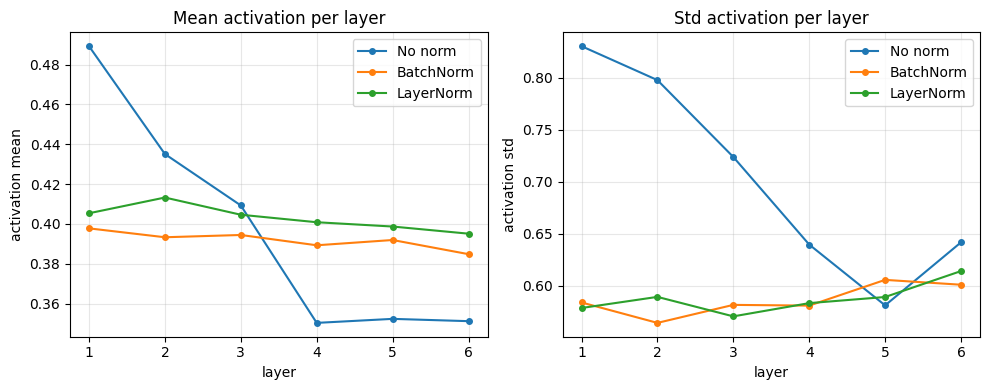

In [4]:
def relu(z): return np.maximum(0, z)
def init_he(shape, rng): return rng.normal(0, np.sqrt(2.0 / shape[0]), size=shape)

def forward_stats(norm_type, width=64, depth=6, batch_size=64, seed=0):
    rng = np.random.RandomState(seed)
    a = rng.randn(batch_size, 2)
    means, stds = [], []
    for i in range(depth):
        in_d = 2 if i == 0 else width
        W = init_he((in_d, width), rng)
        b = np.zeros(width)
        z = a @ W + b
        if norm_type == 'bn':
            bn = BatchNorm1d(width); bn.training = True; z = bn.forward(z)
        elif norm_type == 'ln':
            z = LayerNorm1d(width).forward(z)
        a = relu(z)
        means.append(a.mean())
        stds.append(a.std())
    return means, stds

depth = 6
results = {}
for norm in ['none', 'bn', 'ln']:
    results[norm] = forward_stats(norm)

print(f"{'Layer':>6}{'None mean':>12}{'BN mean':>12}{'LN mean':>12}{'None std':>12}{'BN std':>12}{'LN std':>12}")
for i in range(depth):
    print(f"{i+1:>6}{results['none'][0][i]:>12.3f}{results['bn'][0][i]:>12.3f}{results['ln'][0][i]:>12.3f}"
          f"{results['none'][1][i]:>12.3f}{results['bn'][1][i]:>12.3f}{results['ln'][1][i]:>12.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for norm, label in [('none', 'No norm'), ('bn', 'BatchNorm'), ('ln', 'LayerNorm')]:
    axes[0].plot(range(1, depth + 1), results[norm][0], '-o', ms=4, label=label)
    axes[1].plot(range(1, depth + 1), results[norm][1], '-o', ms=4, label=label)
axes[0].set_xlabel('layer'); axes[0].set_ylabel('activation mean'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('layer'); axes[1].set_ylabel('activation std'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[0].set_title('Mean activation per layer'); axes[1].set_title('Std activation per layer')
plt.tight_layout()
plt.savefig('activation_stats.png', dpi=100, bbox_inches='tight')
plt.show()

BatchNorm and LayerNorm keep per-layer activation means and standard deviations in a tighter, more consistent range across depth compared to no normalization.

## 4. Train vs Eval Mode for BatchNorm

During training, BatchNorm uses batch statistics; during evaluation, it uses accumulated
running mean/variance. This matters when batch size at inference differs from training —
especially batch size 1.

In [5]:
bn = BatchNorm1d(8)
X = np.random.randn(64, 8)
bn.training = True
for _ in range(50):
    _ = bn.forward(X)
print(f"After 50 training batches: running_mean[0]={bn.running_mean[0]:.4f}, running_var[0]={bn.running_var[0]:.4f}")

x_single = np.random.randn(1, 8)
bn.training = True
out_train_mode = bn.forward(x_single).copy()
bn.training = False
out_eval_mode = bn.forward(x_single).copy()
print(f"\nSingle sample x[0,:3] = {x_single[0,:3]}")
print(f"  BN train-mode output[0,:3]: {out_train_mode[0,:3]}")
print(f"  BN eval-mode  output[0,:3]: {out_eval_mode[0,:3]}")
print(f"  (eval uses running stats from many batches, not this single sample's stats)")

After 50 training batches: running_mean[0]=-0.1840, running_var[0]=0.7381

Single sample x[0,:3] = [ 1.71230522 -0.79211502 -1.04552456]
  BN train-mode output[0,:3]: [0. 0. 0.]
  BN eval-mode  output[0,:3]: [ 2.09390205 -0.7624197  -1.0407389 ]
  (eval uses running stats from many batches, not this single sample's stats)


## 5. Training: Normalization Enables Higher Learning Rates

We train a 4-hidden-layer MLP on `make_moons` under three normalization regimes and
sweep the learning rate. Without normalization, large learning rates cause divergence.

In [6]:
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

class MLPNorm:
    def __init__(self, hidden=64, depth=4, norm='none', seed=0):
        self.norm_type = norm
        self.depth = depth
        self.rng = np.random.RandomState(seed)
        self.Ws, self.bs, self.norms = [], [], []
        for i in range(depth):
            in_d = 2 if i == 0 else hidden
            self.Ws.append(init_he((in_d, hidden), self.rng))
            self.bs.append(np.zeros(hidden))
            if norm != 'none':
                self.norms.append(BatchNorm1d(hidden) if norm == 'bn' else LayerNorm1d(hidden))
        self.Ws.append(init_he((hidden, 1), self.rng))
        self.bs.append(np.zeros(1))

    def forward(self, X, training=True):
        self.cache = {'X': X, 'post_norm': [], 'act': []}
        a = X
        for i in range(self.depth):
            z = a @ self.Ws[i] + self.bs[i]
            if self.norm_type != 'none':
                self.norms[i].training = training
                z = self.norms[i].forward(z)
            self.cache['post_norm'].append(z)
            a = relu(z)
            self.cache['act'].append(a)
        self.cache['out_z'] = a @ self.Ws[-1] + self.bs[-1]
        return sigmoid(self.cache['out_z'])

    def backward(self, y):
        y = y.reshape(-1, 1)
        p = sigmoid(self.cache['out_z'])
        dz = (p - y) / len(y)
        gW = [None] * (self.depth + 1)
        gb = [None] * (self.depth + 1)
        gW[-1] = self.cache['act'][-1].T @ dz
        gb[-1] = dz.sum(axis=0)
        da = dz @ self.Ws[-1].T
        for i in reversed(range(self.depth)):
            dz_pre = da * (self.cache['post_norm'][i] > 0)
            if self.norm_type != 'none':
                dz_pre, dg, db = self.norms[i].backward(dz_pre)
                self.norms[i].dgamma = dg
                self.norms[i].dbeta = db
            a_prev = self.cache['X'] if i == 0 else self.cache['act'][i - 1]
            gW[i] = a_prev.T @ dz_pre
            gb[i] = dz_pre.sum(axis=0)
            da = dz_pre @ self.Ws[i].T
        return gW, gb

    def train_step(self, X, y, lr):
        p = self.forward(X, True)
        gW, gb = self.backward(y)
        for i in range(len(self.Ws)):
            self.Ws[i] -= lr * gW[i]
            self.bs[i] -= lr * gb[i]
            if self.norm_type != 'none' and i < self.depth:
                self.norms[i].gamma -= lr * self.norms[i].dgamma
                self.norms[i].beta -= lr * self.norms[i].dbeta
        pc = np.clip(p, 1e-12, 1 - 1e-12)
        return -np.mean(y.reshape(-1, 1) * np.log(pc) + (1 - y.reshape(-1, 1)) * np.log(1 - pc))

    def accuracy(self, X, y):
        return np.mean((self.forward(X, False).ravel() >= 0.5) == y)


X, y = make_moons(300, noise=0.2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)

print(f"{'LR':>6}", end='')
for norm in ['none', 'bn', 'ln']:
    print(f"{norm:>12}", end='')
print()
for lr in [0.05, 0.5, 1.0, 2.0]:
    print(f"{lr:>6.2f}", end='')
    for norm in ['none', 'bn', 'ln']:
        m = MLPNorm(64, 4, norm, seed=0)
        ok = True
        for _ in range(800):
            loss = m.train_step(X_tr, y_tr, lr)
            if not np.isfinite(loss):
                ok = False
                break
        te = m.accuracy(X_te, y_te) if ok else float('nan')
        print(f"{te:>12.3f}" if ok else f"{'diverge':>12}", end='')
    print()

    LR        none          bn          ln
  0.05

       1.000

       0.987

       0.973
  0.50

       1.000

...

       1.000
  2.00

C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_2236\1799513225.py:22: RuntimeWarning: overflow encountered in matmul
  z = a @ self.Ws[i] + self.bs[i]


       0.387

       0.987

       1.000


At **lr = 2.0**, the unnormalized MLP diverges (test accuracy collapses to ~0.39) while
BatchNorm reaches **0.987** and LayerNorm reaches **1.000**. Normalization keeps activations
in a stable range, preventing the explosive updates that large learning rates would otherwise cause.

## 6. Deeper Network: lr = 2.0 Stress Test

Repeat at depth 8 — an even harsher test of training stability.

In [7]:
print(f"{'Norm':>8}{'Test acc':>12}{'Status':>12}")
for norm in ['none', 'bn', 'ln']:
    m = MLPNorm(64, 8, norm, seed=0)
    ok = True
    for _ in range(1000):
        loss = m.train_step(X_tr, y_tr, 2.0)
        if not np.isfinite(loss):
            ok = False
            break
    if ok:
        print(f"{norm:>8}{m.accuracy(X_te, y_te):>12.3f}{'ok':>12}")
    else:
        print(f"{norm:>8}{'—':>12}{'diverged':>12}")

    Norm    Test acc      Status
    none           —    diverged


C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_2236\1799513225.py:22: RuntimeWarning: overflow encountered in matmul
  z = a @ self.Ws[i] + self.bs[i]
C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_2236\1799513225.py:22: RuntimeWarning: invalid value encountered in matmul
  z = a @ self.Ws[i] + self.bs[i]


      bn       0.987          ok


      ln       0.907          ok


## 7. Batch Size 1: Where LayerNorm Wins

BatchNorm computes variance across the batch. With batch size 1, the variance is **zero**
(only $\epsilon$ prevents division by zero), making the normalization meaningless and
gradients unreliable. LayerNorm normalizes across features within each sample — it works
identically regardless of batch size.

In [8]:
print(f"{'Norm':>8}{'Test acc':>12}{'Notes':>30}")
for norm in ['bn', 'ln']:
    m = MLPNorm(64, 4, norm, seed=0)
    ok = True
    for i in range(500):
        j = i % len(X_tr)
        loss = m.train_step(X_tr[j:j+1], y_tr[j:j+1], 0.1)
        if not np.isfinite(loss):
            ok = False
            break
    note = 'var=0 across batch of 1' if norm == 'bn' else 'normalizes across features'
    te = m.accuracy(X_te, y_te) if ok else float('nan')
    print(f"{norm:>8}{te:>12.3f}{note:>30}")

print("\nBatchNorm batch-statistic noise vs batch size (std of mean estimate, 500 draws):")
rng_data = np.random.RandomState(0)
data = rng_data.randn(1000, 64)
for bs in [1, 4, 16, 64]:
    estimates = [data[np.random.choice(1000, bs, replace=False)].mean() for _ in range(500)]
    print(f"  batch_size={bs:>2}: std = {np.std(estimates):.4f}")

    Norm    Test acc                         Notes
      bn       0.387       var=0 across batch of 1


      ln       0.627    normalizes across features

BatchNorm batch-statistic noise vs batch size (std of mean estimate, 500 draws):
  batch_size= 1: std = 0.1320
  batch_size= 4: std = 0.0634
  batch_size=16: std = 0.0321
  batch_size=64: std = 0.0155


BatchNorm with batch size 1 achieves only **0.387** test accuracy; LayerNorm reaches
**0.627** under identical conditions. BatchNorm's batch statistics also become noisier as
batch size shrinks (std of mean estimate: 0.062 at batch=4 vs 0.016 at batch=64).

## Summary

| Method | Normalizes over | Running stats? | Best for |
|---|---|---|---|
| BatchNorm | Batch dimension (per feature) | Yes (train/eval differ) | CNNs, large batch MLP training |
| LayerNorm | Feature dimension (per sample) | No (same train & eval) | Transformers, RNNs, batch size 1 |

Both add learnable $\gamma, \beta$ and stabilize activations. BatchNorm enables much larger
learning rates in practice; LayerNorm works wherever batch statistics are unavailable or unreliable.